# <p style="text-align: center; font-size: 2.5rem">Notebook I</p>

<p style="text-align: center; font-size: 2rem">Part d — Plankton Data EDA</p>

Exploratory data analysis of the cleaned COPEPOD plankton dataset to understand temporal coverage, spatial distribution, and value column completeness before building the time series imputation pipeline.


## Notebook Setup


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from se_coast_strandings import DEFAULT_REGIONS
from se_coast_strandings.contextual_data.plankton_abundance import assign_region
from se_coast_strandings.transformations import make_dt_col

In [45]:
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Load the Cleaned Plankton Data

This parquet file is generated by notebook `01_c_plankton_data_clean.ipynb`. Make sure to run that notebook first.


In [46]:
df = pd.read_parquet(PROCESSED_DIR / "copepod_dataset_se_coast.parquet")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 34,495 rows × 32 columns


,year,month,day,time_gmt,time_local,lat,lon,upper_z,lower_z,grouping_code,...,VALUE-per-area,VALUE-per_area-UNITS,VALUE-per-area-F1,VALUE-per-area-F2,VALUE-per-area-F3,VALUE-per-area-F4,SCIENTIFIC NAME -[ modifiers ]-,RECORD-ID,DATASET-ID,date
0,1995,3,19,11.600,-99.0,40.047,-69.477,10.0,10.0,4320000,...,null,-----,-1,-1,-1,-1,"Chaetognatha ""CPR-TOTAL """"eyecount""""""",0008_0001,SAHFOS-CPR Atlantic Ocean,1995-03-19
1,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212000,...,null,-----,-1,-1,-1,-1,Copepoda TOTAL (total count),0020_0005,SAHFOS-CPR Atlantic Ocean,1995-04-16
2,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,"Calanus ""CPR-TOTAL """"traverse""""""",0020_0004,SAHFOS-CPR Atlantic Ocean,1995-04-16
3,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus TOTAL (total count) -[ c5-6 ]-,0020_0007,SAHFOS-CPR Atlantic Ocean,1995-04-16
4,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus -[ c1-4 ]-,0020_0001,SAHFOS-CPR Atlantic Ocean,1995-04-16


In [47]:
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"  {i:>2}. {col} ({df[col].dtype})")

Columns:
   0. year (int64)
   1. month (int64)
   2. day (int64)
   3. time_gmt (float64)
   4. time_local (float64)
   5. lat (float64)
   6. lon (float64)
   7. upper_z (float64)
   8. lower_z (float64)
   9. grouping_code (int64)
  10. life_stage (int64)
  11. sex (int64)
  12. measurement_type (str)
  13. water_strained (float64)
  14. original_value (str)
  15. original_units (str)
  16. count (str)
  17. VALUE-per_volu-UNITS (str)
  18. global_an_flag (int64)
  19. basin_annu_flag (int64)
  20. basin_seas_flag (int64)
  21. basin_mont_flag (int64)
  22. VALUE-per-area (str)
  23. VALUE-per_area-UNITS (str)
  24. VALUE-per-area-F1 (int64)
  25. VALUE-per-area-F2 (int64)
  26. VALUE-per-area-F3 (int64)
  27. VALUE-per-area-F4 (int64)
  28. SCIENTIFIC NAME -[ modifiers ]- (str)
  29. RECORD-ID (str)
  30. DATASET-ID (str)
  31. date (datetime64[us])


## 2. Temporal Coverage

Explore the date range and frequency of observations.


In [48]:
# Build the date column from YEAR, MON, DAY
df["date"] = make_dt_col(df["day"], df["month"], df["year"])

valid_dates = df["date"].dropna()
print(f"Date range: {valid_dates.min()} to {valid_dates.max()}")
print(f"Records with valid date: {len(valid_dates):,} / {len(df):,}")
print(f"Unique dates: {valid_dates.nunique():,}")

Date range: 1953-02-16 00:00:00 to 2001-12-08 00:00:00
Records with valid date: 34,495 / 34,495
Unique dates: 544


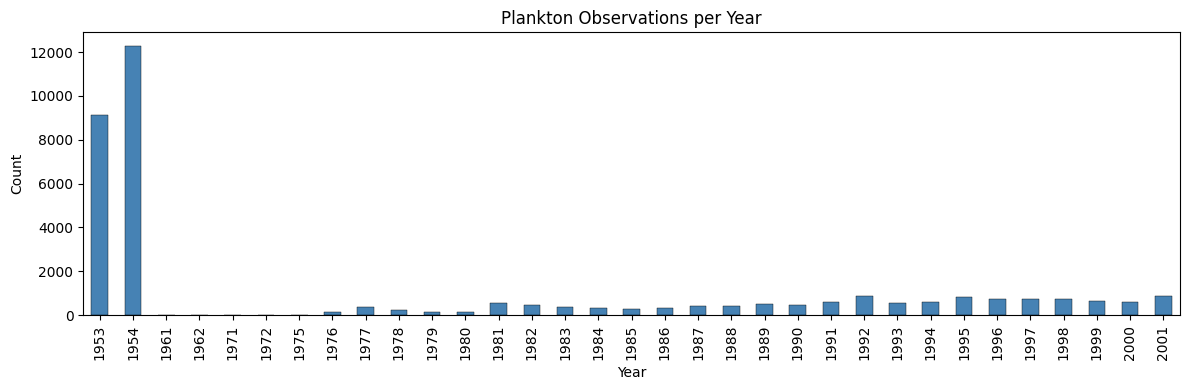

In [49]:
# Observations per year
yearly = df.groupby(df["date"].dt.year).size()

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.3)
ax.set_title("Plankton Observations per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

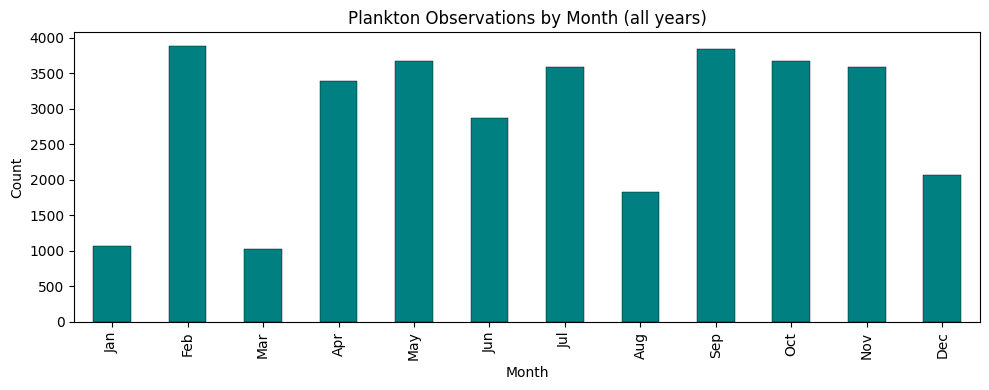

In [50]:
# Observations per month (all years)
monthly = df.groupby(df["date"].dt.month).size()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(kind="bar", ax=ax, color="teal", edgecolor="black", linewidth=0.3)
ax.set_title("Plankton Observations by Month (all years)")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

## 3. Value Column Completeness

Check which plankton density columns have the most data.


In [51]:
value_cols = [c for c in df.columns if c.startswith("VALUE")]

completeness = pd.DataFrame({
    "column": value_cols,
    "non_null": [pd.to_numeric(df[c], errors="coerce").notna().sum() for c in value_cols],
    "pct": [pd.to_numeric(df[c], errors="coerce").notna().mean() * 100 for c in value_cols],
})
completeness = completeness.sort_values("non_null", ascending=False)
print(completeness.to_string(index=False))

              column  non_null        pct
   VALUE-per-area-F1     34495 100.000000
   VALUE-per-area-F2     34495 100.000000
   VALUE-per-area-F3     34495 100.000000
   VALUE-per-area-F4     34495 100.000000
      VALUE-per-area      9090  26.351645
VALUE-per_volu-UNITS         0   0.000000
VALUE-per_area-UNITS         0   0.000000


## 4. Spatial Distribution & Region Assignment

Assign plankton observations to latitude-band regions and see how many observations each region has.


In [52]:
df["region"] = assign_region(df["lat"])

print("Region definitions:")
for label, lat_min, lat_max in DEFAULT_REGIONS:
    count = (df["region"] == label).sum()
    print(f"  {label:>10}: lat [{lat_min:.1f}, {lat_max:.1f})  →  {count:,} observations")

unassigned = df["region"].isna().sum()
print(f"  Unassigned: {unassigned:,}")

Region definitions:
          SC: lat [32.0, 33.5)  →  4,886 observations
    NC-south: lat [33.5, 34.8)  →  3,009 observations
    NC-north: lat [34.8, 36.2)  →  567 observations
          VA: lat [36.2, 38.0)  →  2,408 observations
  Unassigned: 23,625


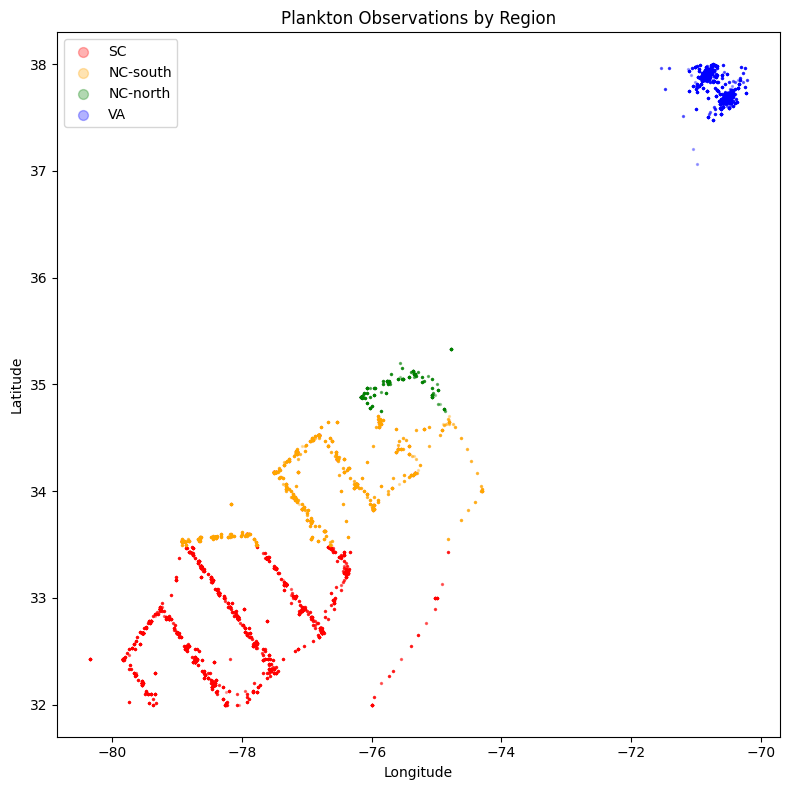

In [53]:
# Scatter plot: observations by lat/lon colored by region
fig, ax = plt.subplots(figsize=(8, 8))

colors = {"SC": "red", "NC-south": "orange", "NC-north": "green", "VA": "blue"}
for label in colors:
    subset = df[df["region"] == label]
    ax.scatter(
        subset["lon"], subset["lat"],
        s=2, alpha=0.3, label=label, color=colors[label]
    )

ax.set_title("Plankton Observations by Region")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 5. Time Series per Region

Plot the plankton density over time for each region to see the gap structure.


In [54]:
# Use the best value column identified from the completeness table above
# Default to VALUE-per-volu-F1; change if another column is better
VALUE_COL = "VALUE-per-area-F1"

df[VALUE_COL] = pd.to_numeric(df[VALUE_COL], errors="coerce")

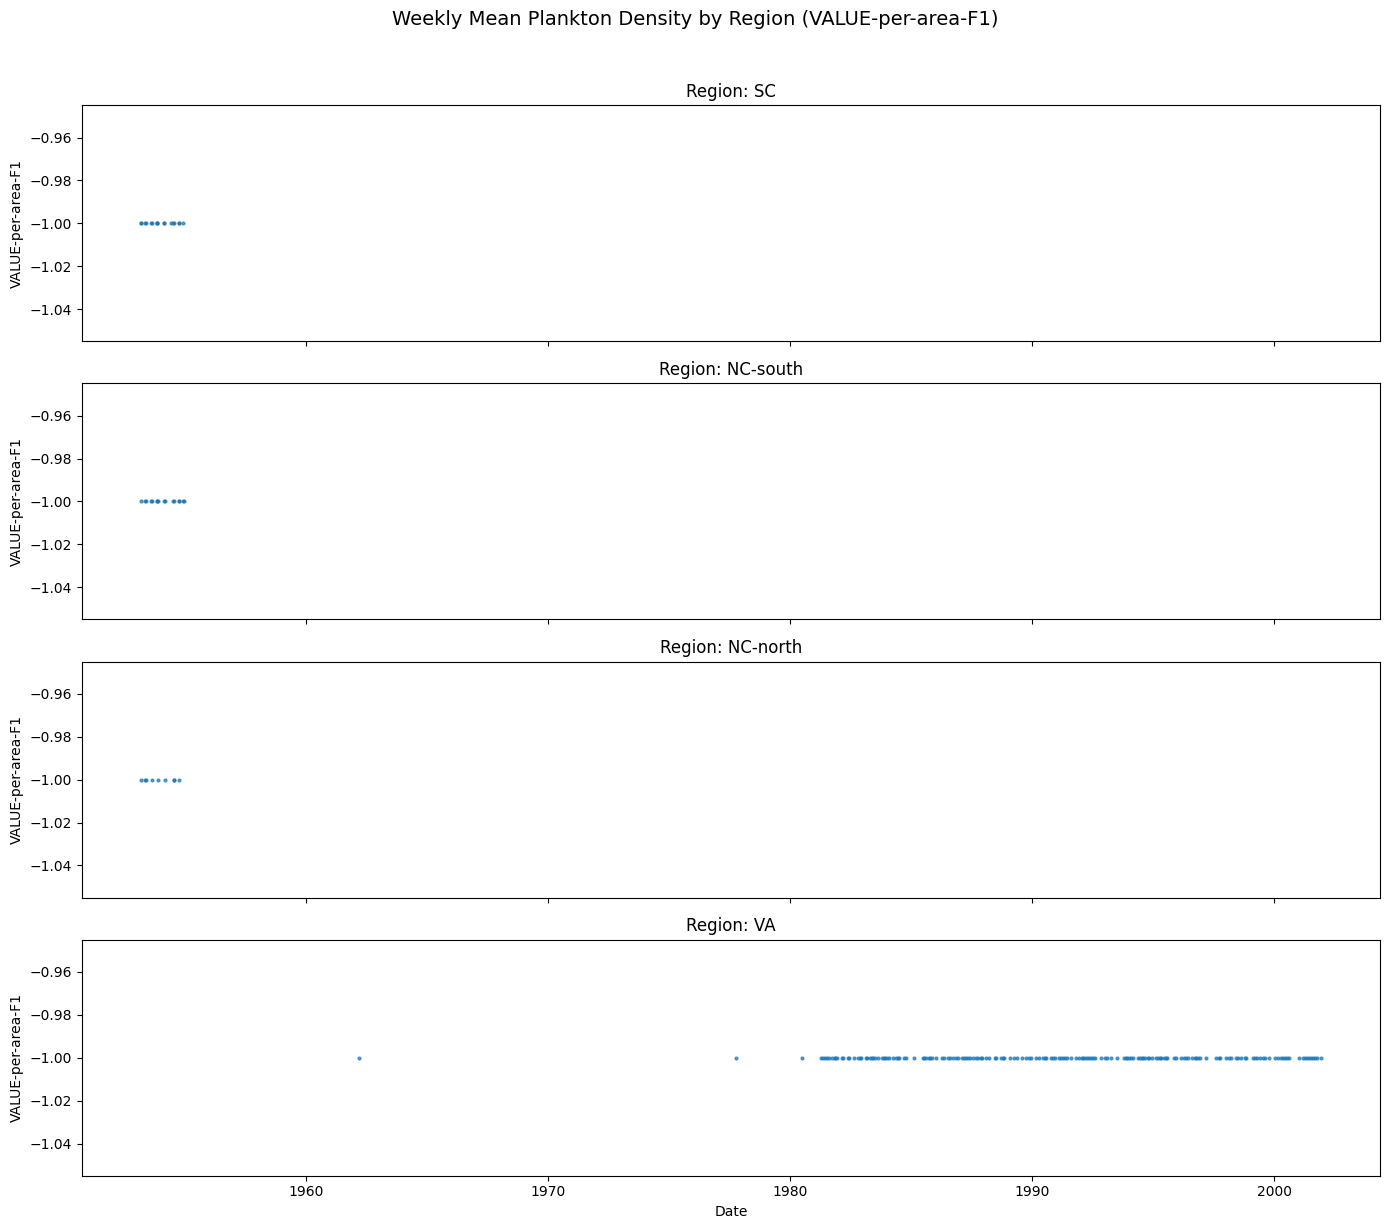

In [55]:
fig, axes = plt.subplots(len(DEFAULT_REGIONS), 1, figsize=(14, 3 * len(DEFAULT_REGIONS)), sharex=True)

for ax, (label, _, _) in zip(axes, DEFAULT_REGIONS):
    subset = df[(df["region"] == label) & df[VALUE_COL].notna()]
    
    if not subset.empty:
        # Weekly mean
        weekly = subset.set_index("date").resample("W")[VALUE_COL].mean()
        ax.plot(weekly.index, weekly.values, "o-", markersize=2, linewidth=0.8, alpha=0.7)
    
    ax.set_title(f"Region: {label}")
    ax.set_ylabel(VALUE_COL)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Weekly Mean Plankton Density by Region ({VALUE_COL})", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Gap Analysis

For each region, look at how long the gaps between observations are.


In [56]:
print("Gap analysis (consecutive weekly periods with no data):")
print()

for label, _, _ in DEFAULT_REGIONS:
    subset = df[(df["region"] == label) & df[VALUE_COL].notna()].copy()
    
    if subset.empty:
        print(f"  {label}: No data with values")
        continue
    
    weekly = subset.set_index("date").resample("W")[VALUE_COL].mean()
    total_weeks = len(pd.date_range(weekly.index.min(), weekly.index.max(), freq="W"))
    filled_weeks = weekly.notna().sum()
    
    # Find gap lengths
    is_gap = weekly.isna()
    gap_groups = (is_gap != is_gap.shift()).cumsum()
    gap_lengths = is_gap.groupby(gap_groups).sum()
    gap_lengths = gap_lengths[gap_lengths > 0]
    
    print(f"  {label}:")
    print(f"    Coverage: {filled_weeks}/{total_weeks} weeks ({filled_weeks/total_weeks*100:.1f}%)")
    if len(gap_lengths) > 0:
        print(f"    Number of gaps: {len(gap_lengths)}")
        print(f"    Median gap: {gap_lengths.median():.0f} weeks")
        print(f"    Max gap: {gap_lengths.max():.0f} weeks")
    print()

Gap analysis (consecutive weekly periods with no data):

  SC:
    Coverage: 17/93 weeks (18.3%)
    Number of gaps: 8
    Median gap: 10 weeks
    Max gap: 14 weeks

  NC-south:
    Coverage: 16/93 weeks (17.2%)
    Number of gaps: 7
    Median gap: 10 weeks
    Max gap: 17 weeks

  NC-north:
    Coverage: 9/83 weeks (10.8%)
    Number of gaps: 6
    Median gap: 12 weeks
    Max gap: 18 weeks

  VA:
    Coverage: 174/2075 weeks (8.4%)
    Number of gaps: 173
    Median gap: 4 weeks
    Max gap: 812 weeks



## Summary

After running the cells above, you should have a clear picture of:

1. **Which value column** to use for the Prophet model (the most complete one)
2. **How many observations** each region has
3. **How sparse** the data is per region (gap structure)
4. **Whether the region definitions** need adjustment

Use this information to proceed with `05_plankton_imputation.ipynb`.
